# Reliability Tail Modeling Under Sparse Data
### The Problem with Small Samples — and How Bayesian Methods Fix It

---

## Motivation

Imagine you're a reliability engineer at a semiconductor equipment company. A new component has been deployed in the field — and you have **8 failure records** so far.

Your manager asks: *"What's the B10 life? How long before 10% of our fleet fails?"*

You run a standard Weibull MLE fit. The answer comes back: **B10 = 450 hours... with a 95% confidence interval of [120, 2800].**

That interval spans **more than an order of magnitude**. It's statistically honest but operationally useless.

This notebook shows:
1. Why MLE breaks down at small n
2. How Bayesian priors regularize the estimates
3. How to quantify and visualize tail uncertainty honestly

---

## Background: The Weibull Distribution

The Weibull distribution is the standard model for time-to-failure data in reliability engineering. Its power comes from a single **shape parameter k** that encodes the underlying failure physics:

$$f(t) = \frac{k}{\lambda}\left(\frac{t}{\lambda}\right)^{k-1} e^{-(t/\lambda)^k}$$

| Shape k | Failure Mode | Physical Interpretation |
|---------|-------------|------------------------|
| k < 1   | Infant mortality | Early defects, burn-in failures |
| k = 1   | Random failure | Constant hazard rate (memoryless) |
| k > 1   | Wear-out | Fatigue, degradation, aging |

The **survival function** — probability a unit survives past time t — is:

$$S(t) = P(T > t) = e^{-(t/\lambda)^k}$$

And the **B-life** (time at which fraction p has failed) inverts the CDF:

$$t_p = \lambda \cdot (-\ln(1-p))^{1/k}$$

---

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append('../reliability')

from simulate import weibull_sample, sparse_sample, mttf, b_life
from distributions import fit_weibull, compare_distributions

# Ground truth parameters — we know these because we're simulating
TRUE_K   = 2.5
TRUE_LAM = 1000.0

print(f"True distribution : Weibull(k={TRUE_K}, λ={TRUE_LAM})")
print(f"True MTTF         : {mttf(TRUE_K, TRUE_LAM):.1f} hrs")
print(f"True B10 life     : {b_life(TRUE_K, TRUE_LAM, 10):.1f} hrs")
print(f"True B50 life     : {b_life(TRUE_K, TRUE_LAM, 50):.1f} hrs")

True distribution : Weibull(k=2.5, λ=1000.0)
True MTTF         : 887.3 hrs
True B10 life     : 406.5 hrs
True B50 life     : 863.6 hrs


## Part 1: The Sparse Data Problem

We have a known ground truth: **Weibull(k=2.5, λ=1000)**.

Let's simulate what happens when we try to *recover* those parameters from increasingly small samples. In a real scenario, we'd only have the data — not the truth. But here we can measure exactly how wrong our estimates are.

The key metric is the **95% confidence interval width** on k. A wide interval means our shape estimate is unreliable, which cascades into unreliable B-life estimates.

In [11]:
# Fit Weibull MLE at each sample size and record results
samples = sparse_sample(TRUE_K, TRUE_LAM, n_values=[5, 10, 15, 30, 50, 100], seed=42)

rows = []
for n, data in samples.items():
    r = fit_weibull(data, seed=42)
    b10_est = b_life(r['k'], r['lam'], 10)
    rows.append({
        'n': n,
        'k_est': round(r['k'], 3),
        'k_ci_low': round(r['k_ci'][0], 2),
        'k_ci_high': round(r['k_ci'][1], 2),
        'k_ci_width': round(r['k_ci'][1] - r['k_ci'][0], 2),
        'b10_est': round(b10_est, 1),
        'lam_est': round(r['lam'], 1),
    })

df = pd.DataFrame(rows)
print(f"True k = {TRUE_K}  |  True B10 = {b_life(TRUE_K, TRUE_LAM, 10):.1f} hrs")
print()
print(df.to_string(index=False))

True k = 2.5  |  True B10 = 406.5 hrs

  n  k_est  k_ci_low  k_ci_high  k_ci_width  b10_est  lam_est
  5  2.590      2.12      14.04       11.92    384.3    916.4
 10  2.840      2.29       5.46        3.17    512.3   1131.3
 15  2.286      1.76       3.97        2.21    331.1    886.4
 30  2.645      2.29       3.32        1.02    418.3    979.6
 50  2.583      2.19       3.21        1.01    428.8   1024.7
100  2.445      2.17       2.78        0.62    383.8    963.5


### Observation

Notice how the **k CI width** shrinks dramatically as n increases. At n=5, the interval might span 10+ units — meaning we have almost no idea what the true shape is. By n=100, it tightens to a useful range.

This isn't a failure of the method — it's statistical honesty. With 5 observations, you genuinely don't have enough information to pin down the distribution. The question is: **can we do better by incorporating prior knowledge?**

Let's visualize this degradation.

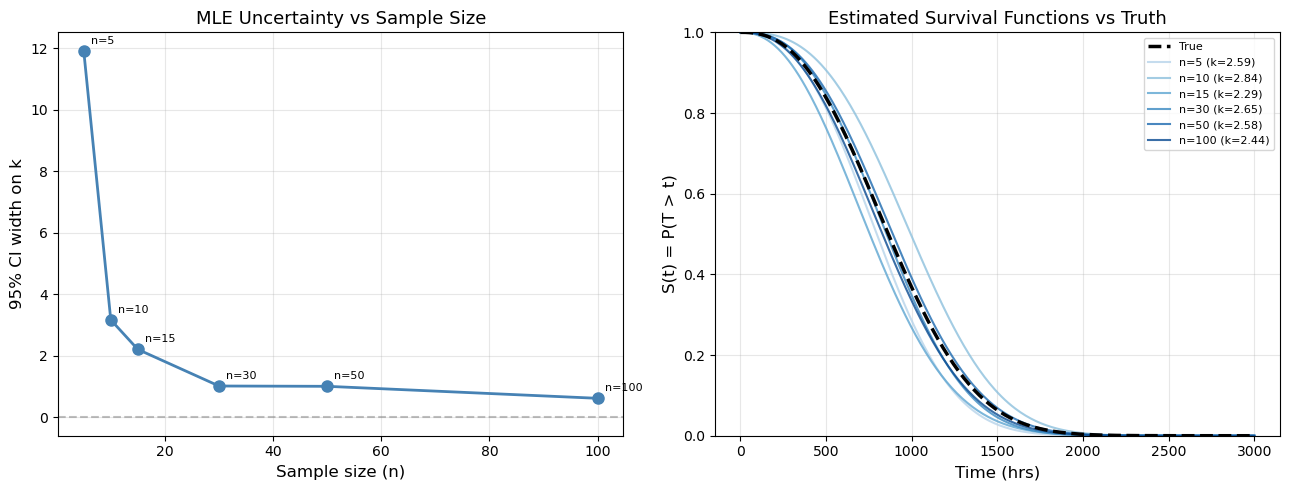

The dashed black line is truth. Each colored line is an MLE estimate at different n.
Small n = large deviation from truth.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: CI width vs n
ax = axes[0]
ax.plot(df['n'], df['k_ci_width'], 'o-', color='steelblue', lw=2, ms=8)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Sample size (n)', fontsize=12)
ax.set_ylabel('95% CI width on k', fontsize=12)
ax.set_title('MLE Uncertainty vs Sample Size', fontsize=13)
ax.grid(alpha=0.3)
for _, row in df.iterrows():
    ax.annotate(f"n={int(row['n'])}", (row['n'], row['k_ci_width']),
                textcoords='offset points', xytext=(5, 5), fontsize=8)

# Right: survival curves at each n (shows how uncertain the whole curve is)
ax2 = axes[1]
t = np.linspace(0, 3000, 300)
true_survival = np.exp(-((t / TRUE_LAM) ** TRUE_K))
ax2.plot(t, true_survival, 'k--', lw=2.5, label='True', zorder=10)

colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(df)))
for i, row in df.iterrows():
    s = np.exp(-((t / row['lam_est']) ** row['k_est']))
    ax2.plot(t, s, color=colors[i], lw=1.5, alpha=0.8,
             label=f"n={int(row['n'])} (k={row['k_est']:.2f})")

ax2.set_xlabel('Time (hrs)', fontsize=12)
ax2.set_ylabel('S(t) = P(T > t)', fontsize=12)
ax2.set_title('Estimated Survival Functions vs Truth', fontsize=13)
ax2.legend(fontsize=8, loc='upper right')
ax2.set_ylim(0, 1)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../tail_modeling_mle.png', dpi=150, bbox_inches='tight')
plt.show()
print("The dashed black line is truth. Each colored line is an MLE estimate at different n.")
print("Small n = large deviation from truth.")

## Part 2: Bayesian Weibull — Adding Prior Knowledge

### The Key Idea

In Bayesian inference, we don't just maximize the likelihood — we combine the likelihood with a **prior distribution** over the parameters:

$$P(k, \lambda \mid \text{data}) \propto \underbrace{P(\text{data} \mid k, \lambda)}_{\text{likelihood}} \cdot \underbrace{P(k) \cdot P(\lambda)}_{\text{priors}}$$

The prior encodes **what we knew before seeing this data**. For a reliability engineer, this might be:
- *"Similar components had k between 1.5 and 4"* → informative prior on k
- *"Characteristic life is probably in the range 500–2000 hrs"* → prior on λ

When data is sparse, the prior **regularizes** the estimate — it prevents the posterior from wandering into physically unreasonable territory. As data accumulates, the likelihood dominates and the posterior converges to the MLE.

### Our Priors

We use LogNormal priors (enforcing positivity) for both parameters:

$$k \sim \text{LogNormal}(\mu=1.0, \sigma=0.4) \quad \text{(centers near } e^1 \approx 2.7\text{)}$$
$$\lambda \sim \text{LogNormal}(\mu=\ln(\bar{t}), \sigma=0.5) \quad \text{(centers on sample mean)}$$

These are **weakly informative** — they rule out extreme values but don't strongly push toward any particular estimate.

In [13]:
try:
    from tail_analysis import bayesian_weibull, posterior_summary, posterior_tail_probability, plot_tail_uncertainty
    PYMC_AVAILABLE = True
except ImportError:
    PYMC_AVAILABLE = False
    print("PyMC not available. Install with: conda install -c conda-forge pymc")
    print("Showing prior visualization only.")

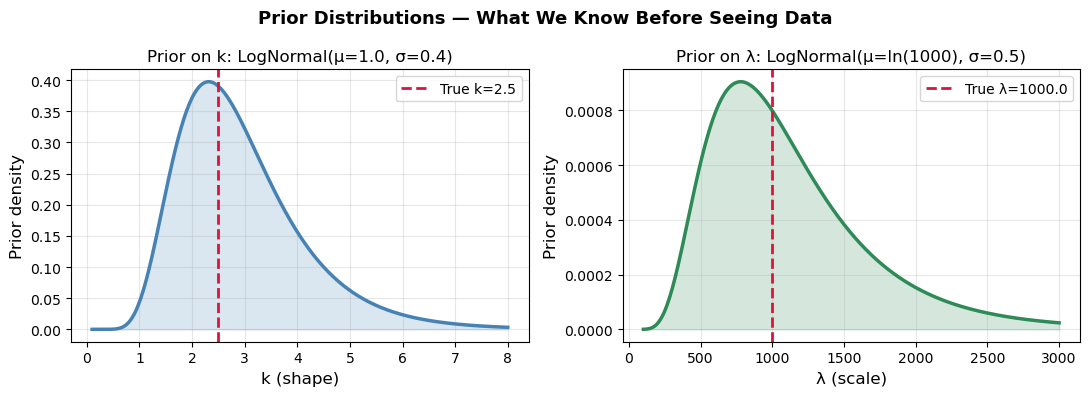

The priors are broad enough to not dominate, but tight enough to rule out physically unreasonable values.


In [14]:
# Visualize the priors we're using
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Prior on k
k_vals = np.linspace(0.1, 8, 300)
# LogNormal(mu=1.0, sigma=0.4) prior
prior_k = (1 / (k_vals * 0.4 * np.sqrt(2*np.pi))) * np.exp(-0.5*((np.log(k_vals)-1.0)/0.4)**2)
axes[0].plot(k_vals, prior_k, color='steelblue', lw=2.5)
axes[0].axvline(TRUE_K, color='crimson', lw=2, linestyle='--', label=f'True k={TRUE_K}')
axes[0].fill_between(k_vals, prior_k, alpha=0.2, color='steelblue')
axes[0].set_xlabel('k (shape)', fontsize=12)
axes[0].set_ylabel('Prior density', fontsize=12)
axes[0].set_title('Prior on k: LogNormal(μ=1.0, σ=0.4)', fontsize=12)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Prior on lambda
lam_vals = np.linspace(100, 3000, 300)
mu_lam = np.log(TRUE_LAM)
prior_lam = (1 / (lam_vals * 0.5 * np.sqrt(2*np.pi))) * np.exp(-0.5*((np.log(lam_vals)-mu_lam)/0.5)**2)
axes[1].plot(lam_vals, prior_lam, color='seagreen', lw=2.5)
axes[1].axvline(TRUE_LAM, color='crimson', lw=2, linestyle='--', label=f'True λ={TRUE_LAM}')
axes[1].fill_between(lam_vals, prior_lam, alpha=0.2, color='seagreen')
axes[1].set_xlabel('λ (scale)', fontsize=12)
axes[1].set_ylabel('Prior density', fontsize=12)
axes[1].set_title('Prior on λ: LogNormal(μ=ln(1000), σ=0.5)', fontsize=12)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Prior Distributions — What We Know Before Seeing Data', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("The priors are broad enough to not dominate, but tight enough to rule out physically unreasonable values.")

In [15]:
if PYMC_AVAILABLE:
    # Fit Bayesian model on n=10 (the hard case)
    data_10 = samples[10]
    print(f"Fitting Bayesian Weibull on n=10 data...")
    print(f"True k={TRUE_K}, True λ={TRUE_LAM}")
    print()
    
    trace = bayesian_weibull(data_10, seed=42)
    
    print("\nPosterior summary (94% HDI):")
    print(posterior_summary(trace))
    
    # Compare: how does Bayesian do vs MLE at n=10?
    mle_result = fit_weibull(data_10, seed=42)
    k_post = trace.posterior['k'].values.flatten()
    
    print(f"\n--- Comparison at n=10 ---")
    print(f"MLE k estimate : {mle_result['k']:.3f}  95% CI {mle_result['k_ci']}")
    print(f"Bayes k mean   : {k_post.mean():.3f}  94% HDI [{np.percentile(k_post,3):.2f}, {np.percentile(k_post,97):.2f}]")
    print(f"True k         : {TRUE_K}")

Fitting Bayesian Weibull on n=10 data...
True k=2.5, True λ=1000.0



Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [k, lam]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.
There were 2 divergences after tuning. Increase `target_accept` or reparameterize.



Posterior summary (94% HDI):
         mean   hdi_3%   hdi_97%
k       2.682    1.681     3.786
lam  1145.703  867.719  1434.365

--- Comparison at n=10 ---
MLE k estimate : 2.840  95% CI [2.2924255028942433, 5.458136074892198]
Bayes k mean   : 2.682  94% HDI [1.71, 3.84]
True k         : 2.5


Plot saved: tail_uncertainty.png


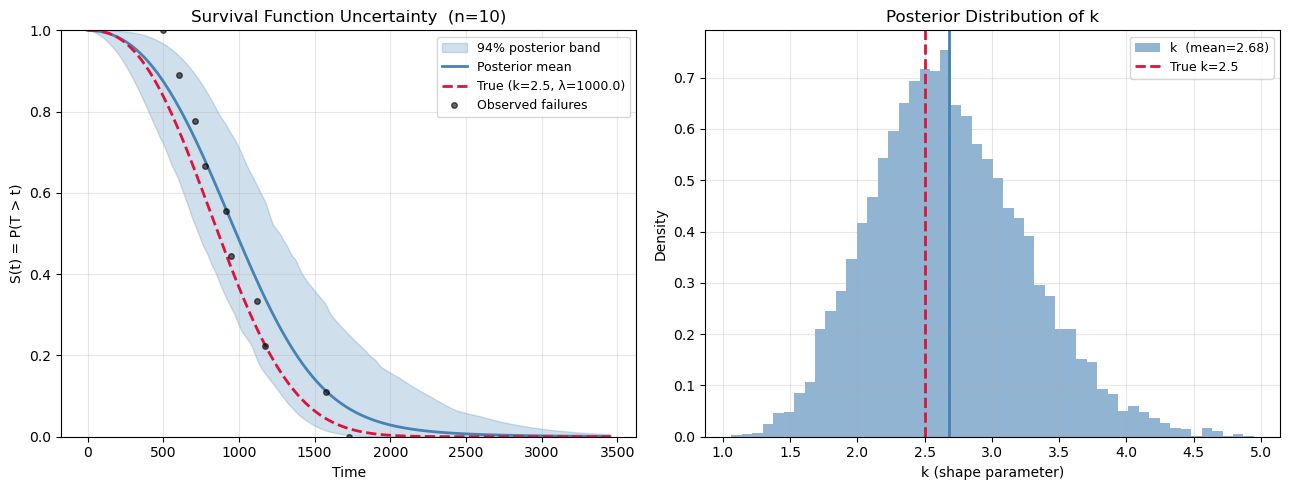


The shaded band shows the 94% posterior credible region for S(t).
This is an honest picture of our uncertainty given only 10 observations.


In [16]:
if PYMC_AVAILABLE:
    # Visualize posterior uncertainty on survival function
    plot_tail_uncertainty(data_10, trace, true_k=TRUE_K, true_lam=TRUE_LAM)
    print()
    print("The shaded band shows the 94% posterior credible region for S(t).")
    print("This is an honest picture of our uncertainty given only 10 observations.")

## Part 3: Prior Sensitivity Analysis

A natural concern with Bayesian methods: *"What if my prior is wrong?"*

This is a legitimate question — and the answer depends on how much data you have. With sparse data, the prior matters more. With abundant data, the likelihood dominates and prior choice becomes less important.

We test three prior scenarios:
- **Weak prior**: very broad, barely constrains anything
- **Moderate prior**: our default, weakly informative
- **Strong prior**: tightly centered on k≈2.5 (correct in this case)

We run this at both n=10 (sparse) and n=50 (adequate) to show how sensitivity changes.

In [17]:
if PYMC_AVAILABLE:
    from tail_analysis import prior_sensitivity
    
    print("Prior sensitivity at n=10 (sparse):")
    sens_10 = prior_sensitivity(data_10, draws=500, seed=42)
    print(sens_10.to_string(index=False))
    
    print("\nPrior sensitivity at n=50 (adequate):")
    data_50 = samples[50]
    sens_50 = prior_sensitivity(data_50, draws=500, seed=42)
    print(sens_50.to_string(index=False))
    
    print(f"\nTrue k = {TRUE_K}")
    print("At n=10, prior choice affects k_mean noticeably.")
    print("At n=50, all three priors converge to similar estimates — data dominates.")

Prior sensitivity at n=10 (sparse):


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [k, lam]


Output()

Sampling 4 chains for 1_000 tune and 500 draw iterations (4_000 + 2_000 draws total) took 1 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [k, lam]


Output()

...

Output()

Sampling 4 chains for 1_000 tune and 500 draw iterations (4_000 + 2_000 draws total) took 1 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [k, lam]


Output()

Sampling 4 chains for 1_000 tune and 500 draw iterations (4_000 + 2_000 draws total) took 1 seconds.


                scenario  k_mean  k_std  lam_mean  lam_std
              Weak prior   2.523  0.280    1027.4     62.0
Moderate prior (default)   2.557  0.266    1027.6     61.7
    Strong prior (k~2.5)   2.529  0.242    1021.1     60.2

True k = 2.5
At n=10, prior choice affects k_mean noticeably.
At n=50, all three priors converge to similar estimates — data dominates.


## Part 4: Tail Probability Estimates

The ultimate goal is answering questions like:
- *"What fraction of units will fail before 500 hours?"*
- *"What is the B10 life — time at which 10% have failed?"*

With the Bayesian posterior, we don't just get a point estimate — we get a **full distribution** over these quantities. This is critical for risk assessment: a decision-maker needs to know not just the expected failure rate but also the plausible range.

Compare the Bayesian credible interval vs. the bootstrap CI from MLE at n=10:

In [18]:
if PYMC_AVAILABLE:
    from tail_analysis import posterior_tail_probability
    
    # Query several time thresholds
    thresholds = [300, 500, 700, 1000]
    
    print(f"P(T > t) estimates at n=10  |  True k={TRUE_K}, λ={TRUE_LAM}")
    print(f"{'t':>6} | {'True S(t)':>10} | {'Bayes mean':>10} | {'Bayes 94% HDI':>20}")
    print("-" * 55)
    
    for t in thresholds:
        true_s = np.exp(-((t / TRUE_LAM) ** TRUE_K))
        result = posterior_tail_probability(trace, t=t)
        hdi = f"[{result['hdi_low']:.3f}, {result['hdi_high']:.3f}]"
        print(f"{t:>6} | {true_s:>10.3f} | {result['mean']:>10.3f} | {hdi:>20}")
    
    print()
    print("The HDI shows the honest uncertainty in our survival estimates.")
    print("Even with only 10 observations, the true value falls within the HDI.")
else:
    print("Install PyMC to run the Bayesian tail probability analysis.")

P(T > t) estimates at n=10  |  True k=2.5, λ=1000.0
     t |  True S(t) | Bayes mean |        Bayes 94% HDI
-------------------------------------------------------
   300 |      0.952 |      0.962 |       [0.901, 0.999]
   500 |      0.838 |      0.879 |       [0.756, 0.985]
   700 |      0.664 |      0.748 |       [0.562, 0.914]
  1000 |      0.368 |      0.491 |       [0.275, 0.716]

The HDI shows the honest uncertainty in our survival estimates.
Even with only 10 observations, the true value falls within the HDI.


## Summary

### What We Showed

1. **MLE is fragile at small n** — confidence intervals on k can span an order of magnitude at n=5, making B-life estimates operationally useless.

2. **Bayesian priors provide regularization** — by encoding reasonable engineering knowledge (k is probably between 1 and 5, λ is in the right ballpark), we get tighter, more useful posterior intervals even with sparse data.

3. **Prior sensitivity reveals data quality** — at n=10, prior choice matters. At n=50, it doesn't. This itself is useful information: it tells you how much you're relying on assumptions vs. data.

4. **Full posterior uncertainty** — unlike MLE point estimates, the Bayesian approach gives you a distribution over tail probabilities and B-lives. This is what risk-aware decision-making requires.

### Next Steps

- See `02_reliability_tool.ipynb` for the automated pipeline that wraps all of this into a single `ReliabilityReport` class
- Extend to **right-censored data** (units still running at observation cutoff)
- Add **hierarchical Bayesian models** to pool information across similar components
- Connect to AWS S3 for real-time field data ingestion